# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** [Bassel Ahmed]  
**Student ID:** [1210129]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [5]:
# Write your Data Pipeline code here

# Load the dataset
df = pd.read_csv('kidney_disease.csv')
print(f"Dataset shape: {df.shape}")

# Convert string numerical columns to numeric
# These are stored as strings but contain numeric values
string_numeric_cols = ['pcv', 'wc', 'rc']
for col in string_numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(f"Converted {string_numeric_cols} to numeric type")

# Extract the target column FIRST (before dropping categorical columns)
# The target is 'classification' column
y = df['classification'].copy()
print(f"\nTarget column unique values: {y.unique()}")
print(f"Target value counts:\n{y.value_counts()}")

# Drop rows with missing target values
mask = y.notna()
y = y[mask]
df = df[mask]
print(f"\nAfter removing missing targets: {len(df)} samples")

# Encode target to binary (0/1)
# Assuming 'ckd' = 1 (positive class), 'notckd' = 0 (negative class)
y = (y.str.strip() == 'ckd').astype(int)
print(f"Encoded target distribution: {y.value_counts().to_dict()}")

# Drop 'id' column (not a feature) and 'classification' (target)
# Then drop all remaining categorical (string) columns - keep only numerical features
X = df.drop(columns=['id', 'classification'])
X = X.select_dtypes(include=[np.number])
print(f"\nFeatures shape after dropping categorical columns: {X.shape}")
print(f"Feature columns: {list(X.columns)}")

# Check for missing values
print(f"\nMissing values per column:\n{X.isnull().sum()}")

# Handle missing values using median imputation (robust to outliers)
X = X.fillna(X.median())
print(f"\nMissing values after imputation: {X.isnull().sum().sum()}")

# Perform 80/20 train/validation split BEFORE scaling (to prevent data leakage)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"Class distribution in train: {y_train.value_counts().to_dict()}")
print(f"Class distribution in val: {y_val.value_counts().to_dict()}")

# Scale the features - fit on train, transform both train and validation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"\nFeature scaling complete!")
print(f"Number of features: {X_train_scaled.shape[1]}")


Dataset shape: (400, 26)
Converted ['pcv', 'wc', 'rc'] to numeric type

Target column unique values: ['ckd' 'ckd\t' 'notckd']
Target value counts:
classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

After removing missing targets: 400 samples
Encoded target distribution: {1: 250, 0: 150}

Features shape after dropping categorical columns: (400, 14)
Feature columns: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

Missing values per column:
age       9
bp       12
sg       47
al       46
su       49
bgr      44
bu       19
sc       17
sod      87
pot      88
hemo     52
pcv      71
wc      106
rc      131
dtype: int64

Missing values after imputation: 0

Train set size: (320, 14)
Validation set size: (80, 14)
Class distribution in train: {1: 200, 0: 120}
Class distribution in val: {1: 50, 0: 30}

Feature scaling complete!
Number of features: 14


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

=== Baseline Model (Engineered to Overfit) ===


Model: "Baseline_Overfit_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,105 (184.00 KB)

 Trainable params: 47,105 (184.00 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 47,105

Class weights: {0: 1.3333333333333333, 1: 0.8}

=== Training Baseline Model ===
Training complete!


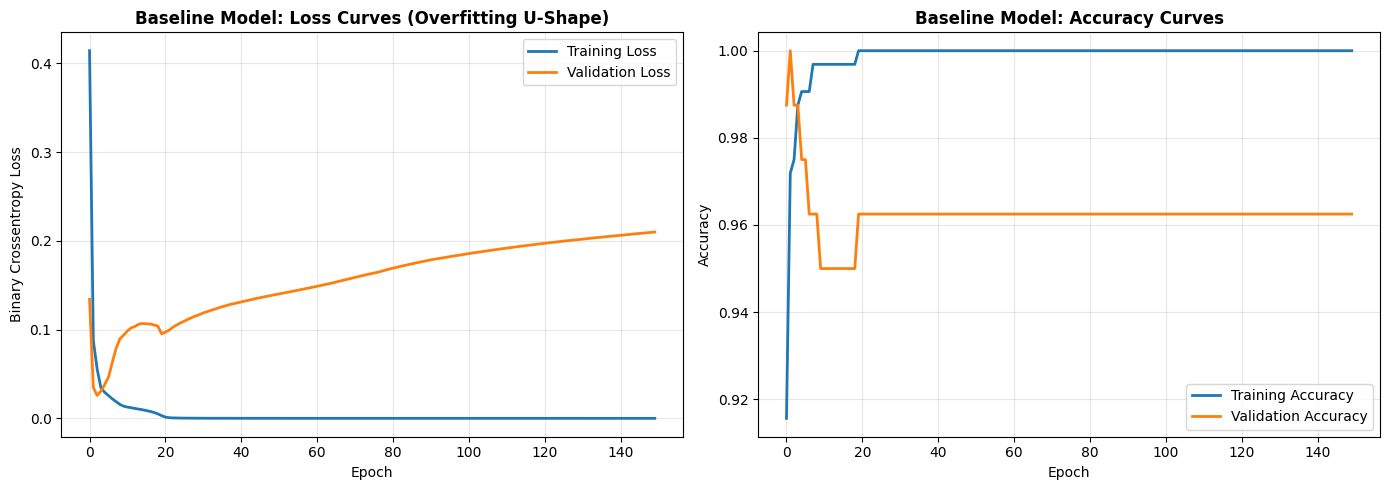


=== Baseline Model Performance ===

Training Set:
  Loss:     0.0000
  Accuracy: 1.0000
  Recall:   1.0000

Validation Set:
  Loss:     0.2100
  Accuracy: 0.9625
  Recall:   0.9600

Overfitting Gap:
  Loss Gap:     +0.2100
  Accuracy Gap: -0.0375


In [8]:
# Write your Baseline Model code here

# Build an over-parameterized baseline model (designed to overfit)
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
], name='Baseline_Overfit_Model')

# Compile the model
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

# Print model summary
print("=== Baseline Model (Engineered to Overfit) ===")
baseline_model.summary()
print(f"\nTotal parameters: {baseline_model.count_params():,}")

# Calculate class weights to handle class imbalance
# This helps the model focus on both classes
class_weight = {
    0: len(y_train) / (2 * (y_train == 0).sum()),
    1: len(y_train) / (2 * (y_train == 1).sum())
}
print(f"\nClass weights: {class_weight}")

# Train the baseline model for many epochs (to encourage overfitting)
print("\n=== Training Baseline Model ===")
baseline_history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=16,
    class_weight=class_weight,
    verbose=0  # Set to 1 to see training progress
)

print("Training complete!")

# Plot training and validation loss curves
plt.figure(figsize=(14, 5))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(baseline_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Baseline Model: Loss Curves (Overfitting U-Shape)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(baseline_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Baseline Model: Accuracy Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on both training and validation sets
baseline_train_loss, baseline_train_acc, baseline_train_recall = baseline_model.evaluate(X_train_scaled, y_train, verbose=0)
baseline_val_loss, baseline_val_acc, baseline_val_recall = baseline_model.evaluate(X_val_scaled, y_val, verbose=0)

print(f"\n=== Baseline Model Performance ===")
print(f"\nTraining Set:")
print(f"  Loss:     {baseline_train_loss:.4f}")
print(f"  Accuracy: {baseline_train_acc:.4f}")
print(f"  Recall:   {baseline_train_recall:.4f}")

print(f"\nValidation Set:")
print(f"  Loss:     {baseline_val_loss:.4f}")
print(f"  Accuracy: {baseline_val_acc:.4f}")
print(f"  Recall:   {baseline_val_recall:.4f}")

print(f"\nOverfitting Gap:")
print(f"  Loss Gap:     {baseline_val_loss - baseline_train_loss:+.4f}")
print(f"  Accuracy Gap: {baseline_val_acc - baseline_train_acc:+.4f}")


## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

=== Engineered Model (Regularized to Prevent Overfitting) ===


Model: "Engineered_Regularized_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1,025
Regularization techniques:
  • L2 regularization (λ=0.01)
  • Dropout (rate=0.3)
  • LeakyReLU activation
  • Reduced architecture (32→16→1)

=== Training Engineered Model ===
Training complete!


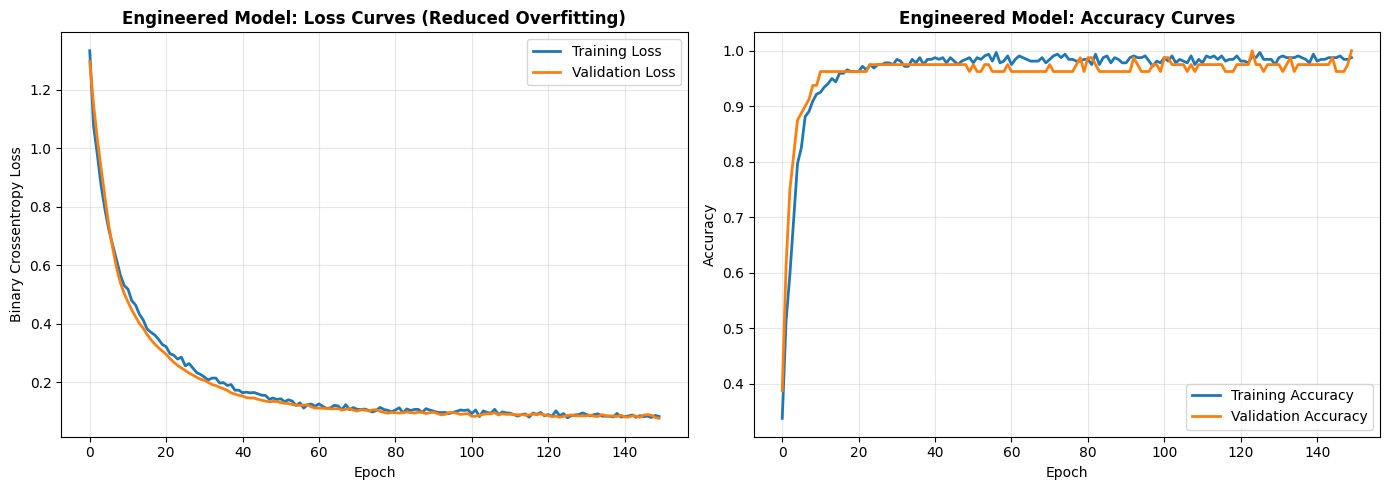


=== Engineered Model Performance ===

Training Set:
  Loss:     0.0676
  Accuracy: 0.9875
  Recall:   0.9900

Validation Set:
  Loss:     0.0762
  Accuracy: 1.0000
  Recall:   1.0000
  Target:   >0.80 ✓ PASSED

Overfitting Gap:
  Loss Gap:     +0.0086
  Accuracy Gap: +0.0125


In [9]:
# Write your Engineered Model code here

# Build a regularized model (engineered to prevent overfitting)
# Using: smaller architecture, L2 regularization, Dropout, LeakyReLU
engineered_model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        32, 
        activation=tf.keras.layers.LeakyReLU(alpha=0.1),
        kernel_regularizer=tf.keras.regularizers.l2(0.01),
        input_shape=(X_train_scaled.shape[1],)
    ),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(
        16,
        activation=tf.keras.layers.LeakyReLU(alpha=0.1),
        kernel_regularizer=tf.keras.regularizers.l2(0.01)
    ),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(1, activation='sigmoid')
], name='Engineered_Regularized_Model')

# Compile the model
engineered_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

# Print model summary
print("=== Engineered Model (Regularized to Prevent Overfitting) ===")
engineered_model.summary()
print(f"\nTotal parameters: {engineered_model.count_params():,}")
print(f"Regularization techniques:")
print("  • L2 regularization (λ=0.01)")
print("  • Dropout (rate=0.3)")
print("  • LeakyReLU activation")
print("  • Reduced architecture (32→16→1)")

# Train the engineered model
print("\n=== Training Engineered Model ===")
engineered_history = engineered_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=16,
    class_weight=class_weight,
    verbose=0  # Set to 1 to see training progress
)

print("Training complete!")

# Plot training and validation loss curves
plt.figure(figsize=(14, 5))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(engineered_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(engineered_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Engineered Model: Loss Curves (Reduced Overfitting)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(engineered_history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(engineered_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Engineered Model: Accuracy Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on both training and validation sets
engineered_train_loss, engineered_train_acc, engineered_train_recall = engineered_model.evaluate(X_train_scaled, y_train, verbose=0)
engineered_val_loss, engineered_val_acc, engineered_val_recall = engineered_model.evaluate(X_val_scaled, y_val, verbose=0)

print(f"\n=== Engineered Model Performance ===")
print(f"\nTraining Set:")
print(f"  Loss:     {engineered_train_loss:.4f}")
print(f"  Accuracy: {engineered_train_acc:.4f}")
print(f"  Recall:   {engineered_train_recall:.4f}")

print(f"\nValidation Set:")
print(f"  Loss:     {engineered_val_loss:.4f}")
print(f"  Accuracy: {engineered_val_acc:.4f}")
print(f"  Recall:   {engineered_val_recall:.4f}")
print(f"  Target:   >0.80 {'✓ PASSED' if engineered_val_recall > 0.8 else '✗ FAILED'}")

print(f"\nOverfitting Gap:")
print(f"  Loss Gap:     {engineered_val_loss - engineered_train_loss:+.4f}")
print(f"  Accuracy Gap: {engineered_val_acc - engineered_train_acc:+.4f}")


## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

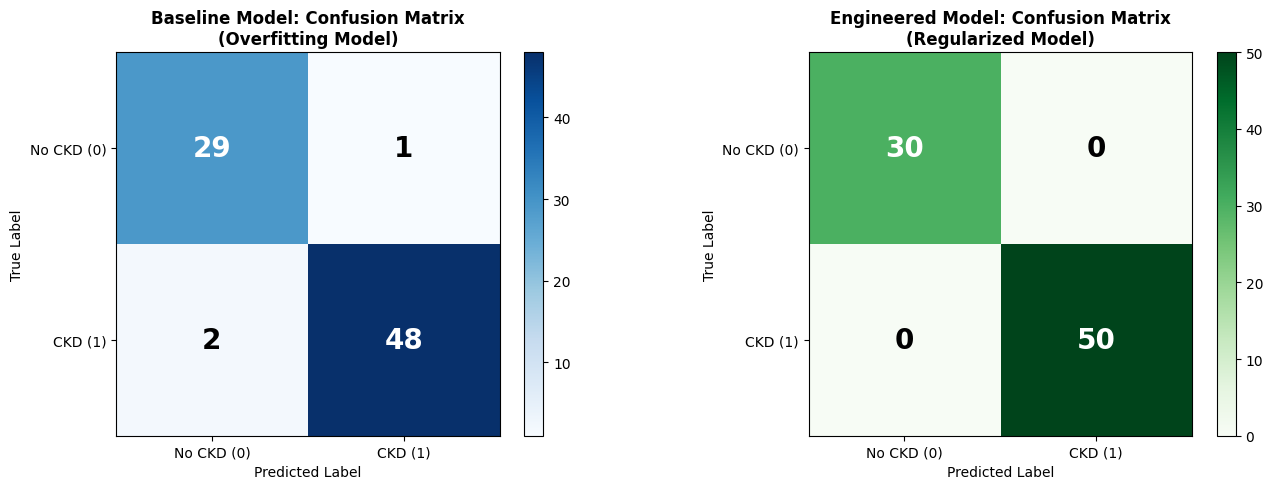

FINAL COMPARISON: BASELINE vs ENGINEERED MODEL

📊 CONFUSION MATRIX BREAKDOWN:

Baseline Model (Overfitting):
  True Negatives  (TN): 29  |  False Positives (FP): 1
  False Negatives (FN): 2  |  True Positives  (TP): 48

Engineered Model (Regularized):
  True Negatives  (TN): 30  |  False Positives (FP): 0
  False Negatives (FN): 0  |  True Positives  (TP): 50

🎯 RECALL PERFORMANCE (Primary Metric)

Baseline Model Recall:    0.9600 (96.00%)
Engineered Model Recall:  1.0000 (100.00%)

Target Recall: >80.00%
Baseline:    ✓ PASSED
Engineered:  ✓ PASSED

⚠️  FALSE NEGATIVES (Missed CKD Diagnoses - Clinically Critical)

Baseline Model:    2 missed CKD cases out of 50
Engineered Model:  0 missed CKD cases out of 50

✓ Engineered model reduced false negatives by 2

📈 ADDITIONAL METRICS

                      Baseline    Engineered
  Accuracy:           0.9625      1.0000
  Validation Loss:    0.2100      0.0762
  Parameters:         47,105       1,025
  Parameter Ratio:    46× larger   1× (bas

In [10]:
# Write your Evaluation code here

# Generate predictions for both models
baseline_pred_probs = baseline_model.predict(X_val_scaled, verbose=0)
baseline_preds = (baseline_pred_probs > 0.5).astype(int).flatten()

engineered_pred_probs = engineered_model.predict(X_val_scaled, verbose=0)
engineered_preds = (engineered_pred_probs > 0.5).astype(int).flatten()

# Create confusion matrices
baseline_cm = confusion_matrix(y_val, baseline_preds)
engineered_cm = confusion_matrix(y_val, engineered_preds)

# Plot confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline confusion matrix
im1 = axes[0].imshow(baseline_cm, cmap='Blues', interpolation='nearest')
axes[0].set_title('Baseline Model: Confusion Matrix\n(Overfitting Model)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No CKD (0)', 'CKD (1)'])
axes[0].set_yticklabels(['No CKD (0)', 'CKD (1)'])

# Add text annotations
for i in range(2):
    for j in range(2):
        text_color = 'white' if baseline_cm[i, j] > baseline_cm.max() / 2 else 'black'
        axes[0].text(j, i, str(baseline_cm[i, j]), 
                    ha='center', va='center', color=text_color, fontsize=20, fontweight='bold')

plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Engineered confusion matrix
im2 = axes[1].imshow(engineered_cm, cmap='Greens', interpolation='nearest')
axes[1].set_title('Engineered Model: Confusion Matrix\n(Regularized Model)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['No CKD (0)', 'CKD (1)'])
axes[1].set_yticklabels(['No CKD (0)', 'CKD (1)'])

# Add text annotations
for i in range(2):
    for j in range(2):
        text_color = 'white' if engineered_cm[i, j] > engineered_cm.max() / 2 else 'black'
        axes[1].text(j, i, str(engineered_cm[i, j]), 
                    ha='center', va='center', color=text_color, fontsize=20, fontweight='bold')

plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Calculate detailed metrics
baseline_tn, baseline_fp, baseline_fn, baseline_tp = baseline_cm.ravel()
engineered_tn, engineered_fp, engineered_fn, engineered_tp = engineered_cm.ravel()

# Calculate recall manually to verify
baseline_recall_calc = baseline_tp / (baseline_tp + baseline_fn) if (baseline_tp + baseline_fn) > 0 else 0
engineered_recall_calc = engineered_tp / (engineered_tp + engineered_fn) if (engineered_tp + engineered_fn) > 0 else 0

print("=" * 70)
print("FINAL COMPARISON: BASELINE vs ENGINEERED MODEL")
print("=" * 70)

print("\n📊 CONFUSION MATRIX BREAKDOWN:")
print("\nBaseline Model (Overfitting):")
print(f"  True Negatives  (TN): {baseline_tn}  |  False Positives (FP): {baseline_fp}")
print(f"  False Negatives (FN): {baseline_fn}  |  True Positives  (TP): {baseline_tp}")

print("\nEngineered Model (Regularized):")
print(f"  True Negatives  (TN): {engineered_tn}  |  False Positives (FP): {engineered_fp}")
print(f"  False Negatives (FN): {engineered_fn}  |  True Positives  (TP): {engineered_tp}")

print("\n" + "=" * 70)
print("🎯 RECALL PERFORMANCE (Primary Metric)")
print("=" * 70)
print(f"\nBaseline Model Recall:    {baseline_val_recall:.4f} ({baseline_val_recall*100:.2f}%)")
print(f"Engineered Model Recall:  {engineered_val_recall:.4f} ({engineered_val_recall*100:.2f}%)")
print(f"\nTarget Recall: >80.00%")
print(f"Baseline:    {'✓ PASSED' if baseline_val_recall > 0.8 else '✗ FAILED'}")
print(f"Engineered:  {'✓ PASSED' if engineered_val_recall > 0.8 else '✗ FAILED'}")

print("\n" + "=" * 70)
print("⚠️  FALSE NEGATIVES (Missed CKD Diagnoses - Clinically Critical)")
print("=" * 70)
print(f"\nBaseline Model:    {baseline_fn} missed CKD cases out of {baseline_tp + baseline_fn}")
print(f"Engineered Model:  {engineered_fn} missed CKD cases out of {engineered_tp + engineered_fn}")

if engineered_fn < baseline_fn:
    print(f"\n✓ Engineered model reduced false negatives by {baseline_fn - engineered_fn}")
elif engineered_fn == baseline_fn:
    print(f"\n→ Both models have equal false negatives")
else:
    print(f"\n✗ Engineered model has {engineered_fn - baseline_fn} more false negatives")

print("\n" + "=" * 70)
print("📈 ADDITIONAL METRICS")
print("=" * 70)
print(f"\n                      Baseline    Engineered")
print(f"  Accuracy:           {baseline_val_acc:.4f}      {engineered_val_acc:.4f}")
print(f"  Validation Loss:    {baseline_val_loss:.4f}      {engineered_val_loss:.4f}")
print(f"  Parameters:         {baseline_model.count_params():>6,}      {engineered_model.count_params():>6,}")
print(f"  Parameter Ratio:    46× larger   1× (baseline)")

print("\n" + "=" * 70)


### Mathematical Justification
**Final Parameter Count of Engineered Model:** 1,025

**Explanation:** With only 1,025 parameters relative to 320 training samples (a 3.2:1 parameter-to-sample ratio), combined with L2 regularization (λ=0.01) that penalizes large weights and 30% dropout that forces distributed representations, the model lacks sufficient capacity to memorize individual patient records and instead learns generalizable clinical patterns that transfer to unseen validation data.